# Lab Session 5

In the fifth session you will be combining what you learned in the previous two sessions (and some new stuff). Once you have mastered this basic knowledge, we can do different things in the coming session(s).

In these exercises you will be looking at a data set containing about 450 thousand (Swedish) Tweets from  September 2018. What is fun to know is that there were general elections on the 9th of September, and that can be seen in the daily tweet-frequency.

***

<div class="alert alert-block alert-warning">
    
## Task 1

Load the data set "september2018.csv", and show the first few lines. If you look at the raw data, it should have three columns called "DateTime", "UserID", and "Tweet". There is one <strong>extra</strong> thing to do this time: we want to convert the DateTime column to a "real" date time in Pandas. Hint: look up the read_csv command again, and read about the parse_dates option.

Write both commands in the next cell, and then execute it. (Give it some time, it may take up to 10 seconds to read the data.)
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [2]:
from datetime import datetime
#Task 1
#Your code here 
dateparse = lambda x: datetime.strptime(x, '%Y%m%d %H:%M:%S')
df = pd.read_csv('september2018.csv', sep=';', parse_dates=['DateTime'], date_parser=dateparse)
df.head()

,DateTime,UserID,Tweet
0,2018-09-01 00:00:07,guldfiske,@detljuvalivet Sen vet jag ju att Politism ha...
1,2018-09-01 00:00:08,oloffjuss,Det är nu det… After Midnight av J.J. Cale ht...
2,2018-09-01 00:00:11,UppsalaTommy,"@hanifbali @konsensuseliten Är du överraskad,..."
3,2018-09-01 00:00:13,ludde67,Då var man här! Hastigt och lustigt och äntli...
4,2018-09-01 00:00:18,tottetudda,Fundering: vad kommer att hända efter valet 9...


<div class="alert alert-block alert-warning">

## Task 2

Lets get into the analysis!

* 2.1 Who has sent out the most tweets this month? Use the countplot() function of seaborn and show the top 10 most active people!
* 2.2 How many users are their in the data? Make sure labels are readable!
* 2.3 Show the number of tweets per day in a bargraph using seaborn! Make sure labels are readable!
</div>

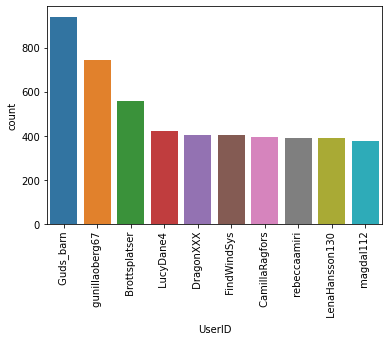

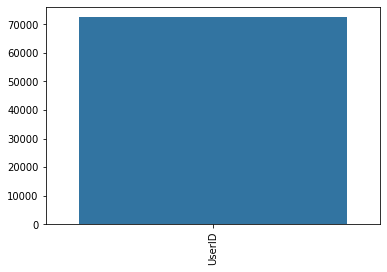

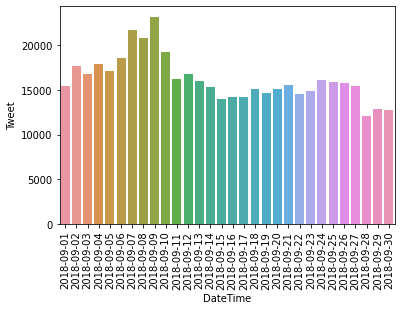

In [3]:
#Task 2.1
plt.figure(1)
#Your code here 
sns.countplot(x='UserID', data=df, order=df['UserID'].value_counts().iloc[:10].index)
plt.xticks(rotation=90)
plt.show()

#Task 2.2
#Your code here
sns.barplot(x=['UserID'], y=[df.groupby(['UserID']).count().reset_index().count()[0]])
plt.xticks(rotation=90)
plt.show()

#Task 2.3
plt.figure(2)
#Your code here 
sns.barplot(x='DateTime', y='Tweet', data=df.groupby(df['DateTime'].dt.date).count().drop(['DateTime'], axis=1).reset_index())
plt.xticks(rotation=90)
plt.show()

<div class="alert alert-block alert-warning">
    
## Task 3

The days around the 9th have seen increased activity! This was infact election day. Lets only look at the day of the election!

* 3.1 Make a new smaller data frame containing only the tweets on the 9th. Call it df1, and print how many tweets there were on that day. Make a bar plot of the number of tweets per hour using seaborn.

* 3.2 Add a new column to df1 called "NumTags" which contains the number of "#" in the "Tweet" column. Hint: look up the Pandas str.count() function. (You will probably get a warning when you execute the code, ignore that for now.)

* 3.3 Who are those hashtag abusers (people that flood their tweets with hashtags)? Print all the names (UserID) of people that have more than 4 hashtags ("NumTags") in their tweets and count the total number of tweets for each of these people (.value_counts()). Only show the top 10 (.head(10)) and save the top 10 in <i>top_tags</i>. Remember: you can use the new column you just created "NumTags" to filter the dataframe. This problem can be done in one line using pandas! To understand the process better, you might want to do this in steps: 1. filter dataframe using "NumTags". 2. Use the UserID column together with value_count() to count the number of tweets per user. 3. use head() to show the top 10 and save the result in top_tags.

* 3.4 Now we have the people (top_tags) that put alot of hashtags in there tweets. From those peoples tweets, extract all tweets with more then 4 hashtags. Remember that top_tags contains the UserIDs of the hashtag abusers. In order to solve this exercise, you can combine several conditions to filter (i.e. df1[condition]) the original dataframe df1 using the column "NumTags" and the UserIDs contained in top_tags. It might look like something like this: df2 = df1[condition1 & condition2] 
    
Now you have all the tweents with alot of hashtags. Let's count how often each hashtag occures in all extracted tweets, i.e. #val2018 : 20, #svepol: 10, etc. We provided you with the dataframe "print_data", your task is to use a barplot to illustrate!


Seems that casino spammers are hard at work!
</div>

Tweets on 2018-09-09 is : 23165


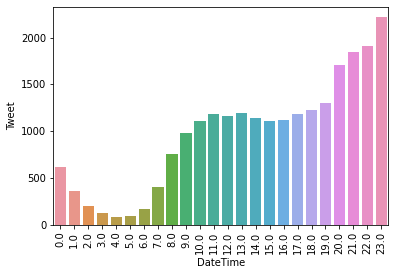

<ipython-input-4-f1d5661d60e6>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["NumTags"] = df1['Tweet'].str.count('#')
<ipython-input-4-f1d5661d60e6>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["Tags"] = df2.Tweet.apply(lambda x: [w for w in x.split() if "#" in w])


UserID        
 Noterad          5
 hilton_dexter    4
 HkanLiljeberg    4
 Erkilainen87     3
 Svensk_Seger     3
 BoerjeBrandt     3
 larsibacken      3
 Ylvass           3
 chrwallg         3
 GittenB          2
dtype: int64


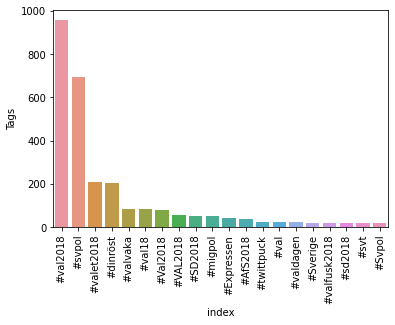

In [4]:
##Task 3.1
#Your code here 
df1 = df[df['DateTime'].dt.date == datetime.strptime('2018-09-09', '%Y-%m-%d').date()]
print("Tweets on 2018-09-09 is :", df1.shape[0])
plt.figure(3)
#Your code here, plot!
sns.barplot(x='DateTime', y='Tweet', data=df.groupby(df1['DateTime'].dt.hour).count().drop(['DateTime'], axis=1).reset_index())
plt.xticks(rotation=90)
plt.show()

#Task 3.2
#Your code here 
df1["NumTags"] = df1['Tweet'].str.count('#')


#Task 3.3
#Your code here 
top_tags = df1[df1['NumTags'] > 4].value_counts(['UserID']).head(10)
print(top_tags)

# #3.4
df2 = df1[df1['NumTags'] > 4 & df1['UserID'].isin([key[0] for key in top_tags.keys()])]

df2["Tags"] = df2.Tweet.apply(lambda x: [w for w in x.split() if "#" in w])
print_data = pd.Series(df2["Tags"].sum()).value_counts().head(20).reset_index(name="Tags")

plt.figure(4)
#Your code here           
sns.barplot(x='index', y='Tags', data=print_data)
plt.xticks(rotation=90)
plt.show()

<div class="alert alert-block alert-warning">
    
## Task 4

Lets look at interactions between users!

* 4.1 Each user has a favorit user to talk to (Identified by the @UserID). Print the number and amount of tweets directed at him/her. i.e.: User1 User2 120. Some steps to acomplish this:
    
    -  4.1.1. Use the .apply() method to extract the Users the tweet is directed at. Use 3.4 (df2["Tags"] = ...) as a guidence on how to extract these users from the tweets using apply. Save the result in the new column "talksto". Remember, tweets directed at specific users include "@UserID" in the message, we therefore can use this to extract the users (like we did in  3.4 to extract hashtags). 
    
    -  4.1.2.For each user, you need to count the occurance of all users (extracted for each tweet before) in the cleaned tweet.
    Tips on how to get going:
        - 4.1.2.1 Use the groupby() method and group by "UserID"
        - 4.1.2.2 On the resulting groupby object call on the cleaned tweets .apply(lambda x: Counter(x.sum()).most_common(1))) and make a dataframe out of the result
        - 4.1.2.3 on the resulting dataframe call .apply(lambda x: x[0][1] if len(x) > 0 else 0) on "talksto" and save the results in "Num"
        - 4.1.2.4 sort dataframe by "Num" decending order and print the top 10.
    

* 4.2 What is the percentage of people that only tweeted once? Remember the "Num" column from before.

* 4.3 What user had the most engangement with different people? Print the number of different people addressed by each user in decending order, print the top 10. Remember 4.1.2.2, use .apply(lambda x: len(set(x.sum()))) instead!

* 4.4 There seems to be an outlier user that tweets to many people! What topic is this user generaly talking about (use google translate)?

* 4.5 Is the user gunillaoberg67 a real person? Look at the tweets and decide!
</div>

In [16]:
#4.1
#most interaction 
def get_talksto(x):
    words = []
    for word in x.split(' '):
        if '@' in word:
            words.append(word)
    return words

#Your code here 
df["talksto"] = df['Tweet'].apply(get_talksto)
df_most = pd.DataFrame(df.groupby('UserID'))
df_most["Num"] = df_most[1].apply(lambda x: Counter(x['talksto'].sum()).most_common(1))
df_most['Num'] = df_most['Num'].apply(lambda x: x[0][1] if len(x) > 0 else 0)
print(df_most.sort_values(['Num'], ascending=False).head(10))


#4.2
#Your code here 
df_most = df.groupby(['UserID']).count()
print(df_most[df_most['Tweet'] == 1]['Tweet'].count() * 100 / df_most.shape[0])

#4.3
#most engangement with different people
#Your code here 
df["talksto"] = df['Tweet'].apply(get_talksto)
df['interect'] = df.groupby(['UserID'])['talksto'].apply(lambda x: len(set(x.sum())))
df_group = df.groupby(['UserID']).count()
df_group['interact'] = df.groupby(['UserID']).apply(lambda x: len(set(x['talksto'].sum())))
print(df_group.sort_values(['interact'], ascending=False).head(10))

print('\n\n')
#4.4
#Your code here      
dfx = df.groupby(['UserID']).count().reset_index()
Q1 = dfx['Tweet'].quantile(0.25)
Q2 = dfx['Tweet'].quantile(0.75)
IQR = Q2 - Q1
lower_lim = Q1 - 0.5 * IQR
higher_lim = Q2 + 0.5 * IQR
outlier_users = dfx[(dfx['Tweet'] < lower_lim) | (dfx['Tweet'] > higher_lim)].sort_values(['Tweet'], ascending=False)
outlier_users.drop(['DateTime'], axis = 1)
print("The outlier user with most tweets is:", outlier_users.iloc[0]['UserID'])
"""
--> By looking at tweets of Guds_barn, it seems that user is mostly tsking about the elections
"""
print('\n\n')
# #4.5
print(df[df.UserID == ' gunillaoberg67']['Tweet'])
# """ By looking at tweets it looks like it is a real person not a bot"""



                      0                                                  1  \
32173          ShabADFA                    DateTime     UserID  \
37102...   
45734        dumskallar                    DateTime       UserID  \
301...   
29375      Provokatoren                    DateTime         UserID  \
1...   
10099     Erik_Olofsson                    DateTime          UserID  \
...   
2446      Andersson_123                    DateTime          UserID  \
...   
48151          fininsyn                    DateTime     UserID  \
13496...   
53025          jespet71                    DateTime     UserID  \
399  ...   
30027   RealNobakhtAhad                    DateTime            UserID  ...   
31735   SaraAnd17564998                    DateTime            UserID  ...   
26929       OMartinsson                    DateTime        UserID  \
63...   

       Num  
32173  133  
45734  114  
29375  101  
10099   91  
2446    68  
48151   66  
53025   65  
30027   64  
31735   61  
26929   60 